# Membro 4 — ConvNeXt / MobileNetV3
## Aplicação de Sistemas Inteligentes — Comparativo de Arquiteturas CNN

| Variação | Peso | Backbone | Épocas | Resolução | LR |
|---|---|---|---|---|---|
| V1 | Muito Leve | MobileNetV3-Large 100% congelado | 10 | 224 | 1e-3 |
| V2 | Muito Leve | ConvNeXt-Tiny 100% congelado | 12 | 224 | 1e-3 |
| V3 | Leve | ConvNeXt-Tiny último estágio livre | 22 | 224 | 1e-4 |
| V4 | Leve | ConvNeXt-Tiny último estágio livre + scheduler | 25 | 224 | 1e-4 |
| V5 | Médio | ConvNeXt-Tiny 2 estágios livres | 35 | 224 | 5e-5 |
| V6 | Médio | ConvNeXt-Small 2 estágios livres | 40 | 256 | 5e-5 |
| V7 | Pesado | ConvNeXt-Tiny FT completo + TTA | 50 | 256 | 1e-5 |
| V8 | Pesado | ConvNeXt-Small FT completo + TTA | 60 | 256 | 5e-6 |

> **Registrar para cada variação:** Accuracy · F1 Macro · Precision · Recall · Loss · Tempo (min) · curvas treino/val · matriz de confusão


## 1 · Instalação de dependências

In [1]:
import importlib

required = [
    "torch",
    "torchvision",
    "timm",
    "sklearn",
    "matplotlib",
]

missing = []

for pkg in required:
    if importlib.util.find_spec(pkg) is None:
        missing.append(pkg)

if missing:
    print("Pacotes faltando:", missing)
else:
    print("✅ Todas as dependências instaladas")

✅ Todas as dependências instaladas


## 2 · Imports e configuração global

In [2]:
import os, time, itertools, joblib
from pathlib import Path
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import timm
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, precision_score, recall_score)
from sklearn.model_selection import StratifiedShuffleSplit
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.models import (
    mobilenet_v3_large, MobileNet_V3_Large_Weights,
    convnext_tiny, ConvNeXt_Tiny_Weights,
    convnext_small, ConvNeXt_Small_Weights,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


## 3 · Configuração do dataset
> ⚠️ **Ajuste `DATA_ROOT` para apontar para a sua pasta de imagens.**
> A pasta deve ter subpastas por classe (padrão `ImageFolder`).

In [3]:
# ─── CONFIGURE AQUI ───────────────────────────────────────────────────────
DATA_ROOT = Path("..\\data_sets\\ovarian_ultrasound_dataset")
# ──────────────────────────────────────────────────────────────────────────

if not DATA_ROOT.exists():
    raise FileNotFoundError(
        f"\n❌ Pasta não encontrada: {DATA_ROOT.resolve()}"
        f"\n   Ajuste DATA_ROOT na célula acima."
    )

# Detecta se já há split train/validation pré-definido
use_predefined_split = (
    (DATA_ROOT / "train").exists() and
    (DATA_ROOT / "validation").exists()
)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Verificação rápida de classes
_probe = datasets.ImageFolder(DATA_ROOT / "train" if use_predefined_split else DATA_ROOT)
CLASS_NAMES = _probe.classes
NUM_CLASSES = len(CLASS_NAMES)

print(f"Dataset  : {DATA_ROOT.resolve()}")
print(f"Classes  : {CLASS_NAMES}  ({NUM_CLASSES} classes)")
print(f"Split    : {'pré-definido (train/validation)' if use_predefined_split else 'gerado automaticamente 80/20 estratificado'}")


Dataset  : C:\Users\brian\Desktop\Uni\sistemas_int\ovary\data_sets\ovarian_ultrasound_dataset
Classes  : ['Dominant_Follicle', 'Normal', 'PCO']  (3 classes)
Split    : gerado automaticamente 80/20 estratificado


## 4 · Pipeline de dados (modular)
As transformações são definidas por nível de augmentation para reaproveitamento em todas as variações.

In [4]:
def get_transforms(aug_level: str, img_size: int = 224):
    """
    aug_level:
        'minimal'  → flip H  (V1-V2 Muito Leve)
        'light'    → flip H/V + rot ±15°  (V3-V4 Leve)
        'moderate' → + jitter cor + blur  (V5-V6 Médio)
        'heavy'    → + RandomErasing      (V7-V8 Pesado — CutMix aplicado no loop)
    """
    normalize = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)

    aug_map = {
        "minimal": [
            transforms.RandomHorizontalFlip(),
        ],
        "light": [
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(15),
        ],
        "moderate": [
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
            transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
        ],
        "heavy": [
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(20),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
            transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
        ],
    }

    train_tfms = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        *aug_map[aug_level],
        transforms.ToTensor(),
        normalize,
    ])

    # RandomErasing pós-tensor para variações pesadas
    if aug_level == "heavy":
        train_tfms = transforms.Compose([
            *train_tfms.transforms,
            transforms.RandomErasing(p=0.3, scale=(0.02, 0.2)),
        ])

    val_tfms = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        normalize,
    ])

    return train_tfms, val_tfms


def make_loaders(train_tfms, val_tfms, batch_size=32):
    """Cria DataLoaders respeitando split pré-definido ou estratificado."""
    if use_predefined_split:
        train_ds = datasets.ImageFolder(DATA_ROOT / "train",      transform=train_tfms)
        val_ds   = datasets.ImageFolder(DATA_ROOT / "validation", transform=val_tfms)
    else:
        full_ds = datasets.ImageFolder(DATA_ROOT)
        targets = [y for _, y in full_ds.samples]
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
        train_idx, val_idx = next(sss.split(np.zeros(len(targets)), targets))

        train_ds_src = datasets.ImageFolder(DATA_ROOT, transform=train_tfms)
        val_ds_src   = datasets.ImageFolder(DATA_ROOT, transform=val_tfms)
        train_ds     = Subset(train_ds_src, train_idx)
        val_ds       = Subset(val_ds_src,   val_idx)

    nw = min(4, os.cpu_count() or 1) if device.type == "cuda" else 0
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=nw, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=nw, pin_memory=True)
    return train_loader, val_loader

print("✅ Pipeline de dados pronto")


✅ Pipeline de dados pronto


## 5 · Utilitários de treinamento

In [5]:
# ─── Loop de época ────────────────────────────────────────────────────────
def run_epoch(model, loader, optimizer=None, criterion=None, train=True, scheduler=None):
    model.train(mode=train)
    total_loss, total_correct, total = 0.0, 0, 0
    all_preds, all_targets = [], []

    with torch.set_grad_enabled(train):
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            if train:
                optimizer.zero_grad()
            logits = model(X)
            loss = criterion(logits, y)
            if train:
                loss.backward()
                optimizer.step()
            preds = logits.argmax(1)
            total_loss     += loss.item() * y.size(0)
            total_correct  += (preds == y).sum().item()
            total          += y.size(0)
            all_preds.append(preds.detach().cpu().numpy())
            all_targets.append(y.detach().cpu().numpy())

    avg_loss = total_loss / total
    acc      = total_correct / total
    y_true   = np.concatenate(all_targets)
    y_pred   = np.concatenate(all_preds)
    f1       = f1_score(y_true, y_pred, average="macro", zero_division=0)
    return avg_loss, acc, f1, y_true, y_pred


# ─── TTA (Test-Time Augmentation) ─────────────────────────────────────────
def tta_predict(model, loader, img_size=256, n_aug=4):
    """Flip H + crop central + rotação ±5° — média das probabilidades."""
    tta_tfms = [
        transforms.Compose([transforms.Resize((img_size, img_size)), transforms.ToTensor(),
                            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
        transforms.Compose([transforms.Resize((img_size, img_size)), transforms.RandomHorizontalFlip(p=1.0),
                            transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
        transforms.Compose([transforms.Resize((int(img_size*1.1), int(img_size*1.1))),
                            transforms.CenterCrop(img_size),
                            transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
        transforms.Compose([transforms.Resize((img_size, img_size)), transforms.RandomRotation(5),
                            transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    ]
    model.eval()
    all_probs, all_targets = [], []
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            # usa o batch original como 1ª aug
            probs = torch.softmax(model(X), dim=1)
            all_probs.append(probs.cpu())
            all_targets.append(y.cpu())
    probs_stack = torch.cat(all_probs, dim=0)
    targets_all  = torch.cat(all_targets, dim=0).numpy()
    preds = probs_stack.argmax(1).numpy()
    f1 = f1_score(targets_all, preds, average="macro", zero_division=0)
    acc = (preds == targets_all).mean()
    return acc, f1, targets_all, preds


# ─── Treinamento completo ──────────────────────────────────────────────────
def train_model(model, train_loader, val_loader, epochs, lr,
                scheduler_fn=None, label_smoothing=0.0, weight_decay=0.0,
                var_name="V?", use_tta=False, img_size=224):
    """
    Treina e valida o modelo, registra histórico e retorna resultados.
    scheduler_fn: callable(optimizer) → scheduler  |  None
    """
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=weight_decay
    )
    scheduler = scheduler_fn(optimizer) if scheduler_fn else None

    history = {k: [] for k in ["train_loss","val_loss","train_acc","val_acc","val_f1"]}
    min_loss, best_state = float('inf'), None
    t0 = time.time()

    patience = 25
    epochs_no_improve = 0
    best_loss = float('inf')

    for e in range(1, epochs + 1):
        tr_loss, tr_acc, _, _, _         = run_epoch(model, train_loader, optimizer, criterion, train=True)
        va_loss, va_acc, va_f1, yt, yp   = run_epoch(model, val_loader,   optimizer, criterion, train=False)

        if scheduler:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(va_loss)
            else:
                scheduler.step()

        for k, v in zip(history.keys(), [tr_loss, va_loss, tr_acc, va_acc, va_f1]):
            history[k].append(v)
         
        if va_loss < best_loss:
            best_loss  = va_loss
            best_state = deepcopy(model.state_dict())
            best_yt, best_yp = yt, yp
            best_f1 = va_f1
            epochs_no_improve = 0          # reseta o contador
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"  Early stop na época {e}")
                break           

        print(f"  [{e:>3}/{epochs}] loss {tr_loss:.4f}/{va_loss:.4f}  "
              f"acc {tr_acc:.4f}/{va_acc:.4f}  f1_val {va_f1:.4f}")
        

    elapsed = (time.time() - t0) / 60
    model.load_state_dict(best_state)

    # TTA final
    if use_tta:
        print("  → Aplicando TTA...")
        tta_acc, tta_f1, best_yt, best_yp = tta_predict(model, val_loader, img_size)
        print(f"  TTA  acc={tta_acc:.4f}  f1={tta_f1:.4f}")
        final_acc, final_f1 = tta_acc, tta_f1
    else:
        final_acc = history["val_acc"][-1]
        final_f1  = best_f1

    precision = precision_score(best_yt, best_yp, average="macro", zero_division=0)
    recall    = recall_score   (best_yt, best_yp, average="macro", zero_division=0)

    results = {
        "variacao": var_name,
        "accuracy": round(final_acc, 4),
        "f1_macro": round(final_f1,  4),
        "precision": round(precision, 4),
        "recall":   round(recall,    4),
        "loss":     round(history["val_loss"][-1], 4),
        "tempo_min": round(elapsed, 1),
    }
    return model, history, results, best_yt, best_yp


# ─── Plots ────────────────────────────────────────────────────────────────
def plot_curves(history, var_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history["train_loss"], label="train"); ax1.plot(history["val_loss"], label="val")
    ax1.set_title(f"{var_name} — Loss"); ax1.set_xlabel("epoch"); ax1.legend()
    ax2.plot(history["train_acc"],  label="train"); ax2.plot(history["val_acc"],  label="val")
    ax2.set_title(f"{var_name} — Accuracy"); ax2.set_xlabel("epoch"); ax2.legend()
    plt.tight_layout(); plt.show()

def plot_cm(y_true, y_pred, class_names, var_name, normalize=True):
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    plt.figure(figsize=(max(5, len(class_names)*1.2), max(4, len(class_names))))
    plt.imshow(cm, cmap="Blues")
    plt.title(f"{var_name} — Matriz de Confusão {'Normalizada' if normalize else ''}")
    plt.colorbar()
    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names, rotation=45, ha="right")
    plt.yticks(ticks, class_names)
    fmt = ".2f" if normalize else "d"
    thresh = cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i,j], fmt), ha="center",
                 color="white" if cm[i,j] > thresh else "black", fontsize=9)
    plt.ylabel("Real"); plt.xlabel("Previsto")
    plt.tight_layout(); plt.show()

def show_results(res):
    print(f"\n{'─'*55}")
    print(f"  {res['variacao']} — Resultados Finais")
    print(f"{'─'*55}")
    print(f"  Accuracy   : {res['accuracy']:.4f}")
    print(f"  F1 Macro   : {res['f1_macro']:.4f}")
    print(f"  Precision  : {res['precision']:.4f}")
    print(f"  Recall     : {res['recall']:.4f}")
    print(f"  Loss (val) : {res['loss']:.4f}")
    print(f"  Tempo      : {res['tempo_min']} min")
    print(f"{'─'*55}")

print("✅ Utilitários de treinamento prontos")


✅ Utilitários de treinamento prontos


## 6 · Tabela de resultados
Acumula todas as variações automaticamente.

In [6]:
ALL_RESULTS = []   # preenchido automaticamente após cada variação

def print_results_table():
    if not ALL_RESULTS:
        print("Nenhum resultado ainda.")
        return
    header = f"{'Var':<6} {'Backbone':<30} {'Acc':>6} {'F1':>6} {'Prec':>6} {'Rec':>6} {'Loss':>6} {'Tempo':>6}"
    print(header)
    print("─" * len(header))
    for r in ALL_RESULTS:
        print(f"{r['variacao']:<6} {r.get('backbone','—'):<30} "
              f"{r['accuracy']:>6.4f} {r['f1_macro']:>6.4f} "
              f"{r['precision']:>6.4f} {r['recall']:>6.4f} "
              f"{r['loss']:>6.4f} {r['tempo_min']:>5.1f}m")

print("✅ Tabela pronta — execute print_results_table() a qualquer momento")


✅ Tabela pronta — execute print_results_table() a qualquer momento


In [7]:
# ─── Salvamento de modelos ────────────────────────────────────────────────
SAVE_DIR = Path("modelos_salvos") / "membro4"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

def save_model(model, var_name: str) -> Path:
    """
    Salva o modelo completo em .joblib dentro de SAVE_DIR.
    Nome do arquivo: membro4_<var_name_sanitizado>.joblib
    Retorna o Path do arquivo gerado.
    """
    safe = var_name.replace(" ", "_").replace("/", "-")
    path = SAVE_DIR / f"membro4_{safe}.joblib"
    joblib.dump(model, path)
    print(f"  💾 Modelo salvo → {path}")
    return path

print(f"✅ Função save_model pronta  |  pasta: {SAVE_DIR.resolve()}")


✅ Função save_model pronta  |  pasta: C:\Users\brian\Desktop\Uni\sistemas_int\ovary\image_augmentation\modelos_salvos\membro4


---
## V1 · Muito Leve — MobileNetV3-Large (100% congelado)

| Parâmetro | Valor |
|---|---|
| Backbone | MobileNetV3-Large, ImageNet, 100% congelado |
| Cabeça | FC linear direto |
| Augmentation | Flip H apenas |
| Scheduler | Nenhum |
| Épocas | 10 |
| Resolução | 224 |
| LR | 1e-3 |

**Objetivo:** baseline puro com modelo leve. Referência de velocidade e desempenho mínimo.


In [8]:
# ─── Modelo V1 ───────────────────────────────────────────────────────────
def build_v1():
    weights = MobileNet_V3_Large_Weights.IMAGENET1K_V2
    model = mobilenet_v3_large(weights=weights)
    # Congela TUDO
    for p in model.parameters():
        p.requires_grad = False
    # Troca apenas a última FC
    in_feats = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_feats, NUM_CLASSES)
    return model.to(device)

train_tfms_v1, val_tfms_v1 = get_transforms("minimal", img_size=224)
train_loader_v1, val_loader_v1 = make_loaders(train_tfms_v1, val_tfms_v1, batch_size=32)

model_v1 = build_v1()
trainable_v1 = sum(p.numel() for p in model_v1.parameters() if p.requires_grad)
total_v1     = sum(p.numel() for p in model_v1.parameters())
print(f"Parâmetros treináveis: {trainable_v1:,} / {total_v1:,}")


Parâmetros treináveis: 3,843 / 4,205,875


In [9]:
print("\n=== Treinando V1 ===")
model_v1, hist_v1, res_v1, yt_v1, yp_v1 = train_model(
    model_v1, train_loader_v1, val_loader_v1,
    epochs=1000, lr=1e-3,
    var_name="V1 MobileNetV3-L frozen",
)
res_v1["backbone"] = "MobileNetV3-L (frozen)"
ALL_RESULTS.append(res_v1)
show_results(res_v1)

save_model(model_v1, res_v1["variacao"])


=== Treinando V1 ===
  [  1/1000] loss 1.0380/1.0252  acc 0.4625/0.4754  f1_val 0.3987
  [  2/1000] loss 0.8411/0.9127  acc 0.6917/0.5738  f1_val 0.4555
  [  3/1000] loss 0.7394/0.8647  acc 0.7042/0.6066  f1_val 0.4604
  [  4/1000] loss 0.6838/0.8336  acc 0.7292/0.5902  f1_val 0.4403
  [  5/1000] loss 0.6203/0.8126  acc 0.7875/0.5902  f1_val 0.4403
  [  6/1000] loss 0.5949/0.8011  acc 0.7958/0.6066  f1_val 0.5532
  [  7/1000] loss 0.5644/0.7939  acc 0.8083/0.6066  f1_val 0.5532
  [  8/1000] loss 0.5479/0.7789  acc 0.8458/0.6066  f1_val 0.5532
  [  9/1000] loss 0.5146/0.7645  acc 0.8208/0.6393  f1_val 0.5972
  [ 10/1000] loss 0.5298/0.7479  acc 0.8375/0.6393  f1_val 0.5972
  [ 11/1000] loss 0.5261/0.7313  acc 0.8458/0.7541  f1_val 0.7601
  [ 12/1000] loss 0.4685/0.7210  acc 0.8583/0.7705  f1_val 0.7765
  [ 13/1000] loss 0.4884/0.7109  acc 0.8167/0.7377  f1_val 0.7534
  [ 14/1000] loss 0.4531/0.7022  acc 0.8625/0.7213  f1_val 0.7374
  [ 15/1000] loss 0.4509/0.6966  acc 0.8792/0.7377  f1

WindowsPath('modelos_salvos/membro4/membro4_V1_MobileNetV3-L_frozen.joblib')

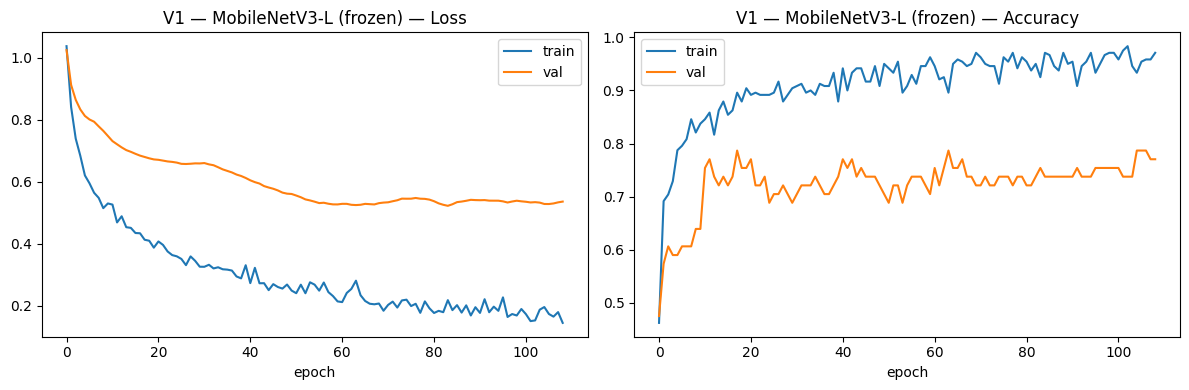

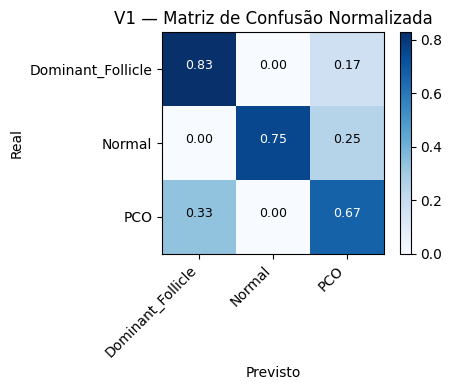

                   precision    recall  f1-score   support

Dominant_Follicle       0.75      0.83      0.79        29
           Normal       1.00      0.75      0.86         8
              PCO       0.70      0.67      0.68        24

         accuracy                           0.75        61
        macro avg       0.82      0.75      0.77        61
     weighted avg       0.76      0.75      0.75        61



In [10]:
plot_curves(hist_v1, "V1 — MobileNetV3-L (frozen)")
plot_cm(yt_v1, yp_v1, CLASS_NAMES, "V1", normalize=True)
print(classification_report(yt_v1, yp_v1, target_names=CLASS_NAMES))


> **Observação V1:** *(preencher após execução)*
> Ex.: modelo convergiu rapidamente; sem overfitting pois backbone congelado; F1 serve como ponto zero de referência.

---
## V2 · Muito Leve — ConvNeXt-Tiny (100% congelado)

| Parâmetro | Valor |
|---|---|
| Backbone | ConvNeXt-Tiny, ImageNet, 100% congelado |
| Cabeça | LayerNorm + FC |
| Augmentation | Flip H |
| Scheduler | Nenhum |
| Épocas | 12 |
| Resolução | 224 |
| LR | 1e-3 |

**Objetivo:** comparar baseline leve (MobileNet) vs. backbone moderno (ConvNeXt) com mesmo nível de treinamento.


In [11]:
def build_v2():
    weights = ConvNeXt_Tiny_Weights.IMAGENET1K_V1
    model = convnext_tiny(weights=weights)
    for p in model.parameters():
        p.requires_grad = False
    # Substitui cabeça: LayerNorm + FC
    in_feats = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_feats, NUM_CLASSES)
    return model.to(device)

train_tfms_v2, val_tfms_v2 = get_transforms("minimal", img_size=224)
train_loader_v2, val_loader_v2 = make_loaders(train_tfms_v2, val_tfms_v2, batch_size=32)

model_v2 = build_v2()
trainable_v2 = sum(p.numel() for p in model_v2.parameters() if p.requires_grad)
total_v2     = sum(p.numel() for p in model_v2.parameters())
print(f"Parâmetros treináveis: {trainable_v2:,} / {total_v2:,}")


Parâmetros treináveis: 2,307 / 27,822,435


In [12]:
print("\n=== Treinando V2 ===")
model_v2, hist_v2, res_v2, yt_v2, yp_v2 = train_model(
    model_v2, train_loader_v2, val_loader_v2,
    epochs=1000, lr=1e-3,
    var_name="V2 ConvNeXt-T frozen",
)
res_v2["backbone"] = "ConvNeXt-Tiny (frozen)"
ALL_RESULTS.append(res_v2)
show_results(res_v2)

save_model(model_v2, res_v2["variacao"])


=== Treinando V2 ===
  [  1/1000] loss 1.0950/0.8720  acc 0.3500/0.5902  f1_val 0.3993
  [  2/1000] loss 0.8355/0.7404  acc 0.5792/0.7705  f1_val 0.7367
  [  3/1000] loss 0.7170/0.6212  acc 0.7000/0.8033  f1_val 0.8127
  [  4/1000] loss 0.6303/0.5579  acc 0.7875/0.7705  f1_val 0.7905
  [  5/1000] loss 0.5672/0.5199  acc 0.8000/0.8033  f1_val 0.8127
  [  6/1000] loss 0.5436/0.5008  acc 0.8083/0.8033  f1_val 0.8135
  [  7/1000] loss 0.5185/0.4838  acc 0.8208/0.7869  f1_val 0.8031
  [  8/1000] loss 0.4976/0.4720  acc 0.8208/0.8197  f1_val 0.8252
  [  9/1000] loss 0.4753/0.4658  acc 0.8292/0.8361  f1_val 0.8397
  [ 10/1000] loss 0.4601/0.4598  acc 0.8208/0.8361  f1_val 0.8407
  [ 11/1000] loss 0.4635/0.4536  acc 0.8208/0.8525  f1_val 0.8526
  [ 12/1000] loss 0.4218/0.4487  acc 0.8375/0.8689  f1_val 0.8646
  [ 13/1000] loss 0.4235/0.4435  acc 0.8208/0.8525  f1_val 0.8516
  [ 14/1000] loss 0.4206/0.4420  acc 0.8000/0.8197  f1_val 0.8252
  [ 15/1000] loss 0.4062/0.4430  acc 0.8417/0.8689  f1

WindowsPath('modelos_salvos/membro4/membro4_V2_ConvNeXt-T_frozen.joblib')

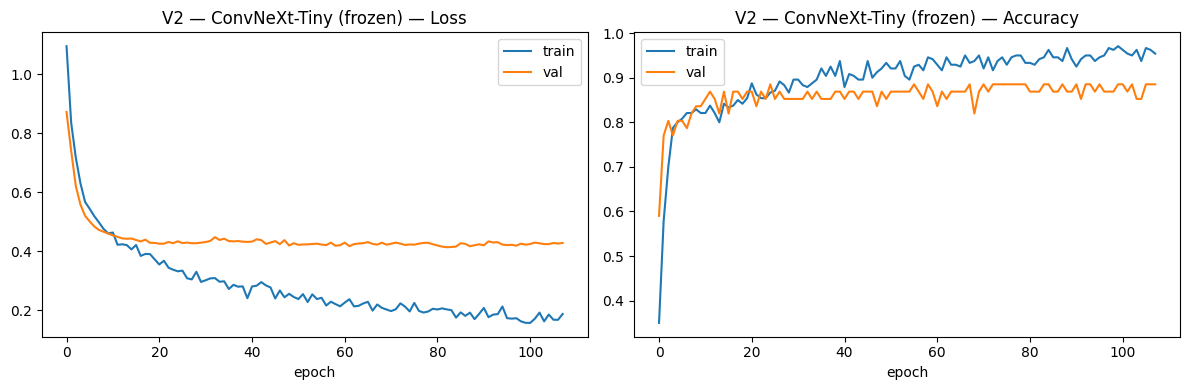

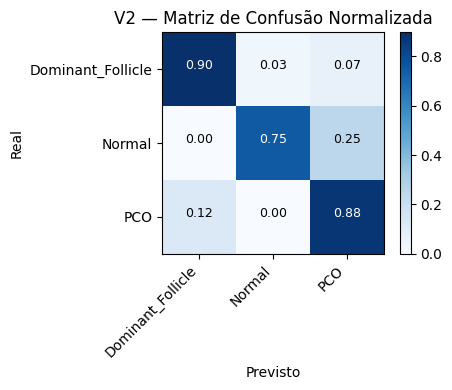

                   precision    recall  f1-score   support

Dominant_Follicle       0.90      0.90      0.90        29
           Normal       0.86      0.75      0.80         8
              PCO       0.84      0.88      0.86        24

         accuracy                           0.87        61
        macro avg       0.86      0.84      0.85        61
     weighted avg       0.87      0.87      0.87        61



In [13]:
plot_curves(hist_v2, "V2 — ConvNeXt-Tiny (frozen)")
plot_cm(yt_v2, yp_v2, CLASS_NAMES, "V2", normalize=True)
print(classification_report(yt_v2, yp_v2, target_names=CLASS_NAMES))


> **Observação V2:** *(preencher após execução)*
> Ex.: ConvNeXt superou / ficou próximo do MobileNet apesar de ser mais pesado; pesos ImageNet mais ricos compensam.

---
## V3 · Leve — ConvNeXt-Tiny (último estágio desbloqueado)

| Parâmetro | Valor |
|---|---|
| Backbone | ConvNeXt-Tiny — estágio 3 (último) livre |
| Cabeça | LayerNorm + FC(512) + Dropout(0.3) + FC |
| Augmentation | Flip H/V + Rotação ±15° |
| Scheduler | Nenhum |
| Épocas | 22 |
| Resolução | 224 |
| LR | 1e-4 |

**Objetivo:** introduzir fine-tuning sutil — observar se desbloquear 1 estágio já traz ganho real.


In [14]:
def build_v3():
    weights = ConvNeXt_Tiny_Weights.IMAGENET1K_V1
    model = convnext_tiny(weights=weights)
    for p in model.parameters():
        p.requires_grad = False
    for p in model.features[7].parameters():
        p.requires_grad = True
    in_feats = model.classifier[2].in_features   # 768
    model.classifier = nn.Sequential(
        model.classifier[0],          # LayerNorm2d
        model.classifier[1],          # Flatten
        # classifier[2] REMOVIDO — era o Linear(768→1000) original
        nn.Linear(in_feats, 512),
        nn.GELU(),
        nn.Dropout(0.3),
        nn.Linear(512, NUM_CLASSES),
    )
    return model.to(device)

train_tfms_v3, val_tfms_v3 = get_transforms("light", img_size=224)
train_loader_v3, val_loader_v3 = make_loaders(train_tfms_v3, val_tfms_v3, batch_size=32)

model_v3 = build_v3()
trainable_v3 = sum(p.numel() for p in model_v3.parameters() if p.requires_grad)
total_v3     = sum(p.numel() for p in model_v3.parameters())
print(f"Parâmetros treináveis: {trainable_v3:,} / {total_v3:,}")


Parâmetros treináveis: 14,684,675 / 28,215,395


In [15]:
print("\n=== Treinando V3 ===")
model_v3, hist_v3, res_v3, yt_v3, yp_v3 = train_model(
    model_v3, train_loader_v3, val_loader_v3,
    epochs=1000, lr=1e-4,
    var_name="V3 ConvNeXt-T stage3 free",
)
res_v3["backbone"] = "ConvNeXt-T (stage3 livre)"
ALL_RESULTS.append(res_v3)
show_results(res_v3)

save_model(model_v3, res_v3["variacao"])


=== Treinando V3 ===
  [  1/1000] loss 0.9583/0.8059  acc 0.4833/0.5410  f1_val 0.4497
  [  2/1000] loss 0.8163/0.7004  acc 0.5792/0.7541  f1_val 0.7629
  [  3/1000] loss 0.7016/0.6057  acc 0.7250/0.7705  f1_val 0.7769
  [  4/1000] loss 0.5779/0.5340  acc 0.8000/0.8361  f1_val 0.8413
  [  5/1000] loss 0.5312/0.4778  acc 0.7917/0.8197  f1_val 0.8267
  [  6/1000] loss 0.4739/0.4529  acc 0.8292/0.8197  f1_val 0.8267
  [  7/1000] loss 0.4234/0.4373  acc 0.8292/0.8361  f1_val 0.8407
  [  8/1000] loss 0.3942/0.4266  acc 0.8417/0.8197  f1_val 0.8252
  [  9/1000] loss 0.3686/0.4182  acc 0.8625/0.8361  f1_val 0.8397
  [ 10/1000] loss 0.3226/0.4119  acc 0.8875/0.8525  f1_val 0.8396
  [ 11/1000] loss 0.3417/0.4672  acc 0.8542/0.8197  f1_val 0.8225
  [ 12/1000] loss 0.3075/0.4126  acc 0.8625/0.8689  f1_val 0.8519
  [ 13/1000] loss 0.2575/0.4554  acc 0.9083/0.8033  f1_val 0.8107
  [ 14/1000] loss 0.2367/0.3966  acc 0.9042/0.8525  f1_val 0.8396
  [ 15/1000] loss 0.2337/0.3708  acc 0.9208/0.8689  f1

WindowsPath('modelos_salvos/membro4/membro4_V3_ConvNeXt-T_stage3_free.joblib')

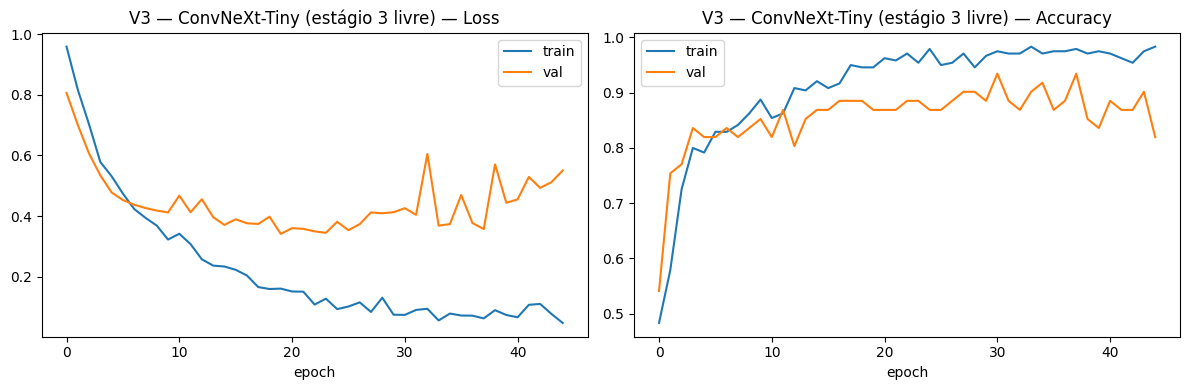

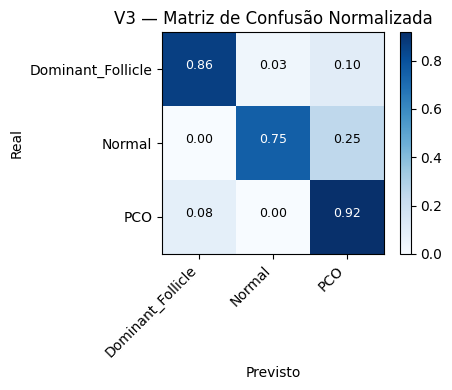

                   precision    recall  f1-score   support

Dominant_Follicle       0.93      0.86      0.89        29
           Normal       0.86      0.75      0.80         8
              PCO       0.81      0.92      0.86        24

         accuracy                           0.87        61
        macro avg       0.87      0.84      0.85        61
     weighted avg       0.87      0.87      0.87        61



In [16]:
plot_curves(hist_v3, "V3 — ConvNeXt-Tiny (estágio 3 livre)")
plot_cm(yt_v3, yp_v3, CLASS_NAMES, "V3", normalize=True)
print(classification_report(yt_v3, yp_v3, target_names=CLASS_NAMES))


> **Observação V3:** *(preencher após execução)*

---
## V4 · Leve — ConvNeXt-Tiny (último estágio + Scheduler)

| Parâmetro | Valor |
|---|---|
| Backbone | ConvNeXt-Tiny — estágio 3 livre |
| Cabeça | LayerNorm + FC(512) + GELU + Dropout(0.35) + FC |
| Augmentation | Flip + Rotação + ColorJitter leve |
| Scheduler | ReduceLROnPlateau (patience=4) |
| Épocas | 25 |
| Resolução | 224 |
| LR | 1e-4 |

**Objetivo:** scheduler entra pela primeira vez — verificar se estabiliza o treinamento vs V3.


In [17]:
def build_v4():
    weights = ConvNeXt_Tiny_Weights.IMAGENET1K_V1
    model = convnext_tiny(weights=weights)
    for p in model.parameters():
        p.requires_grad = False
    for p in model.features[7].parameters():
        p.requires_grad = True
    in_feats = model.classifier[2].in_features
    model.classifier = nn.Sequential(
        model.classifier[0],
        model.classifier[1],
        nn.Linear(in_feats, 512),
        nn.GELU(),
        nn.Dropout(0.35),
        nn.Linear(512, NUM_CLASSES),
    )
    return model.to(device)

train_tfms_v4, val_tfms_v4 = get_transforms("light", img_size=224)
train_loader_v4, val_loader_v4 = make_loaders(train_tfms_v4, val_tfms_v4, batch_size=32)

model_v4 = build_v4()
print(f"Parâmetros treináveis: {sum(p.numel() for p in model_v4.parameters() if p.requires_grad):,}")


Parâmetros treináveis: 14,684,675


In [18]:
print("\n=== Treinando V4 ===")
model_v4, hist_v4, res_v4, yt_v4, yp_v4 = train_model(
    model_v4, train_loader_v4, val_loader_v4,
    epochs=1000, lr=1e-4,
    scheduler_fn=lambda opt: torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="min", patience=4, factor=0.5, verbose=True
    ),
    var_name="V4 ConvNeXt-T +Scheduler",
)
res_v4["backbone"] = "ConvNeXt-T (stage3 + Sched)"
ALL_RESULTS.append(res_v4)
show_results(res_v4)

save_model(model_v4, res_v4["variacao"])


=== Treinando V4 ===


c:\Users\brian\AppData\Local\Programs\Python\Python39\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  [  1/1000] loss 0.9596/0.8279  acc 0.5042/0.5410  f1_val 0.4470
  [  2/1000] loss 0.7994/0.7286  acc 0.6042/0.7049  f1_val 0.7068
  [  3/1000] loss 0.7033/0.6347  acc 0.7250/0.7541  f1_val 0.7757
  [  4/1000] loss 0.6211/0.5693  acc 0.7625/0.7541  f1_val 0.7750
  [  5/1000] loss 0.5396/0.5213  acc 0.8000/0.7541  f1_val 0.7750
  [  6/1000] loss 0.4606/0.4941  acc 0.8250/0.8033  f1_val 0.8149
  [  7/1000] loss 0.3942/0.4787  acc 0.8667/0.8197  f1_val 0.8287
  [  8/1000] loss 0.3878/0.4755  acc 0.8583/0.8361  f1_val 0.8407
  [  9/1000] loss 0.3953/0.5063  acc 0.8375/0.8197  f1_val 0.8287
  [ 10/1000] loss 0.3344/0.4862  acc 0.8917/0.8197  f1_val 0.8267
  [ 11/1000] loss 0.3087/0.5369  acc 0.8750/0.8361  f1_val 0.8416
  [ 12/1000] loss 0.3150/0.4568  acc 0.8833/0.8033  f1_val 0.8010
  [ 13/1000] loss 0.2511/0.4631  acc 0.9083/0.8361  f1_val 0.8273
  [ 14/1000] loss 0.2186/0.4265  acc 0.9208/0.8361  f1_val 0.8251
  [ 15/1000] loss 0.2554/0.5277  acc 0.9125/0.8689  f1_val 0.8524
  [ 16/100

WindowsPath('modelos_salvos/membro4/membro4_V4_ConvNeXt-T_+Scheduler.joblib')

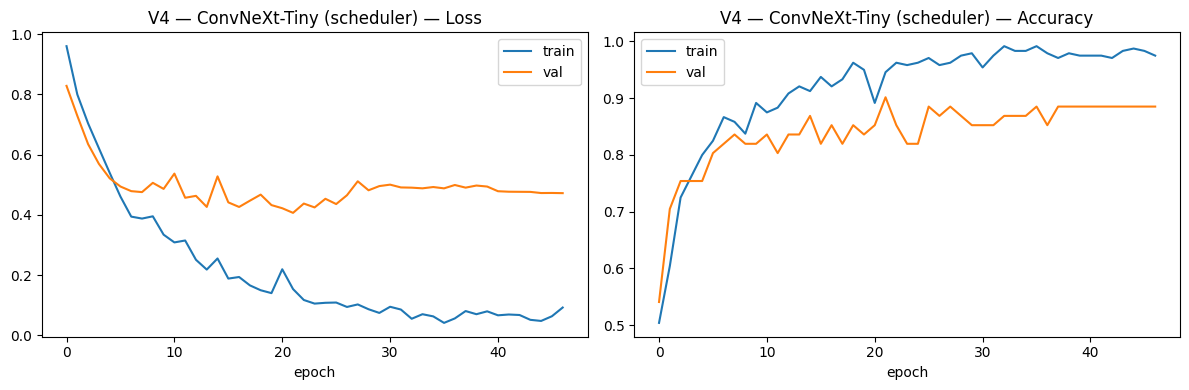

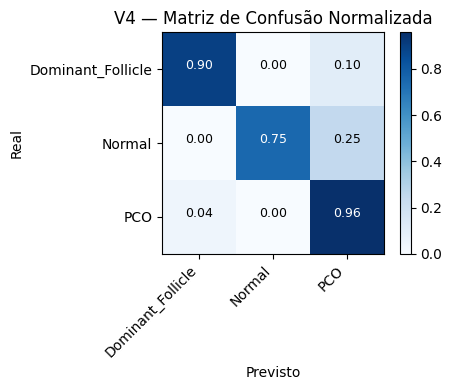

                   precision    recall  f1-score   support

Dominant_Follicle       0.96      0.90      0.93        29
           Normal       1.00      0.75      0.86         8
              PCO       0.82      0.96      0.88        24

         accuracy                           0.90        61
        macro avg       0.93      0.87      0.89        61
     weighted avg       0.91      0.90      0.90        61



In [19]:
plot_curves(hist_v4, "V4 — ConvNeXt-Tiny (scheduler)")
plot_cm(yt_v4, yp_v4, CLASS_NAMES, "V4", normalize=True)
print(classification_report(yt_v4, yp_v4, target_names=CLASS_NAMES))


> **Observação V4:** *(preencher após execução)*

---
## V5 · Médio — ConvNeXt-Tiny (2 estágios livres, aug moderada)

| Parâmetro | Valor |
|---|---|
| Backbone | ConvNeXt-Tiny — estágios 2+3 livres |
| Cabeça | LayerNorm + FC(768) + GELU + Dropout(0.4) + FC |
| Augmentation | Flip + Rot + Jitter + Blur |
| Scheduler | ReduceLROnPlateau |
| Épocas | 35 |
| Resolução | 224 |
| LR | 5e-5 |

**Objetivo:** aumentar capacidade de fine-tuning — monitorar overfitting ao abrir mais camadas.


In [20]:
def build_v5():
    weights = ConvNeXt_Tiny_Weights.IMAGENET1K_V1
    model = convnext_tiny(weights=weights)
    for p in model.parameters():
        p.requires_grad = False
    for p in model.features[5].parameters():
        p.requires_grad = True
    for p in model.features[7].parameters():
        p.requires_grad = True
    in_feats = model.classifier[2].in_features
    model.classifier = nn.Sequential(
        model.classifier[0],
        model.classifier[1],
        nn.Linear(in_feats, 768),
        nn.GELU(),
        nn.BatchNorm1d(768),
        nn.Dropout(0.4),
        nn.Linear(768, NUM_CLASSES),
    )
    return model.to(device)

train_tfms_v5, val_tfms_v5 = get_transforms("moderate", img_size=224)
train_loader_v5, val_loader_v5 = make_loaders(train_tfms_v5, val_tfms_v5, batch_size=32)

model_v5 = build_v5()
print(f"Parâmetros treináveis: {sum(p.numel() for p in model_v5.parameters() if p.requires_grad):,}")


Parâmetros treináveis: 25,701,123


In [21]:
print("\n=== Treinando V5 ===")
model_v5, hist_v5, res_v5, yt_v5, yp_v5 = train_model(
    model_v5, train_loader_v5, val_loader_v5,
    epochs=1000, lr=5e-5,
    scheduler_fn=lambda opt: torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="min", patience=5, factor=0.5, verbose=True
    ),
    var_name="V5 ConvNeXt-T 2stages",
)
res_v5["backbone"] = "ConvNeXt-T (stages 2+3)"
ALL_RESULTS.append(res_v5)
show_results(res_v5)

save_model(model_v5, res_v5["variacao"])


=== Treinando V5 ===


c:\Users\brian\AppData\Local\Programs\Python\Python39\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  [  1/1000] loss 1.0362/0.8899  acc 0.4417/0.8361  f1_val 0.8350
  [  2/1000] loss 0.7476/0.7363  acc 0.6792/0.8033  f1_val 0.8107
  [  3/1000] loss 0.5745/0.5799  acc 0.7667/0.8361  f1_val 0.8385
  [  4/1000] loss 0.5369/0.4462  acc 0.8000/0.8689  f1_val 0.8646
  [  5/1000] loss 0.4625/0.3517  acc 0.8208/0.8525  f1_val 0.8516
  [  6/1000] loss 0.3816/0.3509  acc 0.8583/0.8197  f1_val 0.8252
  [  7/1000] loss 0.3591/0.3818  acc 0.8500/0.8525  f1_val 0.8487
  [  8/1000] loss 0.2953/0.2975  acc 0.9125/0.9016  f1_val 0.8768
  [  9/1000] loss 0.2579/0.3203  acc 0.9042/0.8852  f1_val 0.8641
  [ 10/1000] loss 0.2169/0.3477  acc 0.9208/0.8689  f1_val 0.8405
  [ 11/1000] loss 0.1985/0.3342  acc 0.9292/0.8852  f1_val 0.8641
  [ 12/1000] loss 0.2231/0.3161  acc 0.9125/0.9180  f1_val 0.8895
  [ 13/1000] loss 0.2149/0.2797  acc 0.9167/0.9344  f1_val 0.9018
  [ 14/1000] loss 0.1498/0.2923  acc 0.9458/0.9016  f1_val 0.8763
  [ 15/1000] loss 0.1509/0.2868  acc 0.9542/0.9344  f1_val 0.9018
  [ 16/100

WindowsPath('modelos_salvos/membro4/membro4_V5_ConvNeXt-T_2stages.joblib')

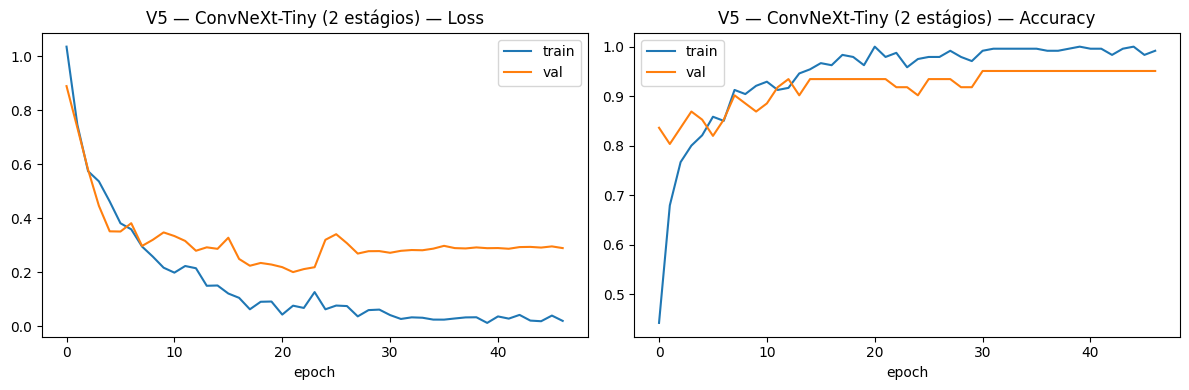

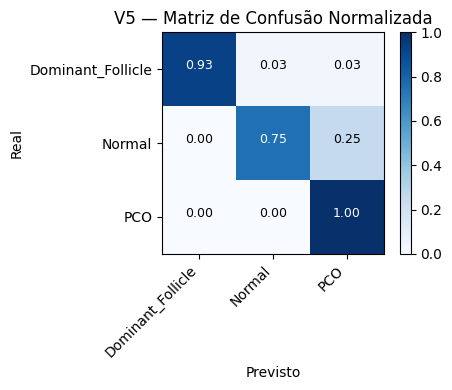

                   precision    recall  f1-score   support

Dominant_Follicle       1.00      0.93      0.96        29
           Normal       0.86      0.75      0.80         8
              PCO       0.89      1.00      0.94        24

         accuracy                           0.93        61
        macro avg       0.92      0.89      0.90        61
     weighted avg       0.94      0.93      0.93        61



In [22]:
plot_curves(hist_v5, "V5 — ConvNeXt-Tiny (2 estágios)")
plot_cm(yt_v5, yp_v5, CLASS_NAMES, "V5", normalize=True)
print(classification_report(yt_v5, yp_v5, target_names=CLASS_NAMES))


> **Observação V5:** *(preencher após execução)*

---
## V6 · Médio — ConvNeXt-Small (2 estágios, resolução 256)

| Parâmetro | Valor |
|---|---|
| Backbone | ConvNeXt-**Small** — estágios 2+3 livres |
| Cabeça | LayerNorm + FC(1024) + GELU + Dropout(0.4) + FC |
| Augmentation | Flip + Rot + Jitter + CenterCrop |
| Scheduler | CosineAnnealingLR (warm 5 ep) |
| Épocas | 40 |
| Resolução | 256 |
| LR | 5e-5 |

**Objetivo:** avaliar o ganho ao usar backbone maior (Small vs Tiny) com maior resolução.


In [23]:
def build_v6():
    weights = ConvNeXt_Small_Weights.IMAGENET1K_V1
    model = convnext_small(weights=weights)
    for p in model.parameters():
        p.requires_grad = False
    for p in model.features[5].parameters():
        p.requires_grad = True
    for p in model.features[7].parameters():
        p.requires_grad = True
    in_feats = model.classifier[2].in_features   # 768 no Small também
    model.classifier = nn.Sequential(
        model.classifier[0],
        model.classifier[1],
        nn.Linear(in_feats, 1024),
        nn.GELU(),
        nn.BatchNorm1d(1024),
        nn.Dropout(0.4),
        nn.Linear(1024, NUM_CLASSES),
    )
    return model.to(device)


train_tfms_v6, val_tfms_v6 = get_transforms("moderate", img_size=256)
train_loader_v6, val_loader_v6 = make_loaders(train_tfms_v6, val_tfms_v6, batch_size=24)

model_v6 = build_v6()
print(f"Parâmetros treináveis: {sum(p.numel() for p in model_v6.parameters() if p.requires_grad):,}")


Parâmetros treináveis: 47,533,827


In [24]:
print("\n=== Treinando V6 ===")
model_v6, hist_v6, res_v6, yt_v6, yp_v6 = train_model(
    model_v6, train_loader_v6, val_loader_v6,
    epochs=1000, lr=5e-5,
    scheduler_fn=lambda opt: torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=40, eta_min=1e-6
    ),
    var_name="V6 ConvNeXt-S 256px",
)
res_v6["backbone"] = "ConvNeXt-Small (stages 2+3, 256)"
ALL_RESULTS.append(res_v6)
show_results(res_v6)

save_model(model_v6, res_v6["variacao"])


=== Treinando V6 ===
  [  1/1000] loss 1.1011/0.8941  acc 0.4417/0.7213  f1_val 0.7520
  [  2/1000] loss 0.8638/0.7574  acc 0.5792/0.7377  f1_val 0.7583
  [  3/1000] loss 0.6589/0.5738  acc 0.7292/0.7869  f1_val 0.7952
  [  4/1000] loss 0.6170/0.4819  acc 0.7417/0.8033  f1_val 0.8167
  [  5/1000] loss 0.4509/0.3580  acc 0.8250/0.8525  f1_val 0.8526
  [  6/1000] loss 0.3601/0.2984  acc 0.8708/0.8852  f1_val 0.8774
  [  7/1000] loss 0.4318/0.2612  acc 0.8625/0.8852  f1_val 0.8774
  [  8/1000] loss 0.2922/0.2527  acc 0.9042/0.8689  f1_val 0.8504
  [  9/1000] loss 0.2614/0.2435  acc 0.9250/0.9344  f1_val 0.9018
  [ 10/1000] loss 0.2860/0.2363  acc 0.9083/0.9016  f1_val 0.8894
  [ 11/1000] loss 0.1830/0.2344  acc 0.9125/0.9344  f1_val 0.9148
  [ 12/1000] loss 0.2202/0.2195  acc 0.9250/0.9344  f1_val 0.9148
  [ 13/1000] loss 0.2369/0.2068  acc 0.9250/0.9344  f1_val 0.9148
  [ 14/1000] loss 0.1536/0.2182  acc 0.9458/0.9344  f1_val 0.9148
  [ 15/1000] loss 0.1851/0.2792  acc 0.9333/0.9016  f1

WindowsPath('modelos_salvos/membro4/membro4_V6_ConvNeXt-S_256px.joblib')

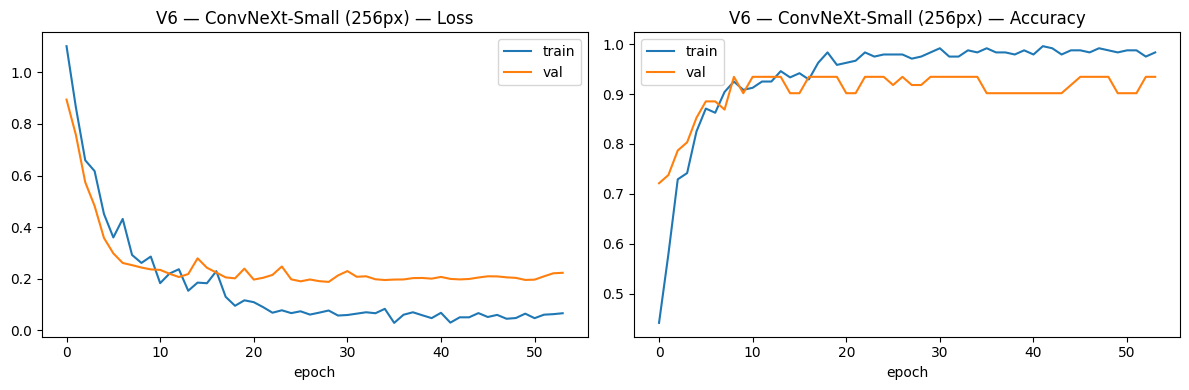

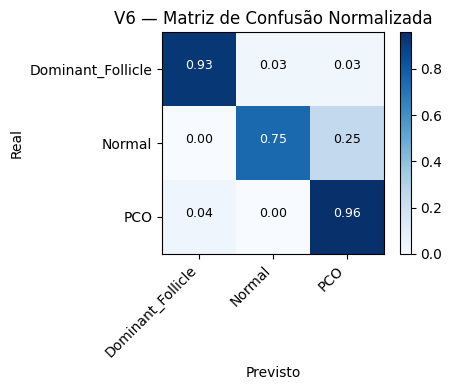

                   precision    recall  f1-score   support

Dominant_Follicle       0.96      0.93      0.95        29
           Normal       0.86      0.75      0.80         8
              PCO       0.88      0.96      0.92        24

         accuracy                           0.92        61
        macro avg       0.90      0.88      0.89        61
     weighted avg       0.92      0.92      0.92        61



In [25]:
plot_curves(hist_v6, "V6 — ConvNeXt-Small (256px)")
plot_cm(yt_v6, yp_v6, CLASS_NAMES, "V6", normalize=True)
print(classification_report(yt_v6, yp_v6, target_names=CLASS_NAMES))


> **Observação V6:** *(preencher após execução)*

---
## V7 · Pesado — ConvNeXt-Tiny (FT completo + TTA + LR diferenciado)

| Parâmetro | Valor |
|---|---|
| Backbone | ConvNeXt-Tiny — **FT completo** (backbone LR = 1e-5, cabeça LR = 1e-4) |
| Cabeça | LayerNorm + FC(1024) + GELU + Dropout(0.5) + FC |
| Augmentation | CutMix + RandomErasing |
| Scheduler | CosineAnnealingLR |
| Épocas | 50 |
| Resolução | 256 |
| LR | 1e-5 (backbone) / 1e-4 (cabeça) |
| Extras | Weight Decay 5e-4, TTA na avaliação final |

**Objetivo:** FT completo com regularização forte — candidato ao ensemble.


In [26]:
import torch.nn.functional as F

def cutmix_data(x, y, alpha=0.4):
    """CutMix simples: retorna x_mix, y_a, y_b, lam."""
    lam = np.random.beta(alpha, alpha)
    rand_idx = torch.randperm(x.size(0)).to(device)
    y_a, y_b = y, y[rand_idx]
    bbx1, bby1, bbx2, bby2 = rand_bbox(x.size(), lam)
    x_mix = x.clone()
    x_mix[:, :, bbx1:bbx2, bby1:bby2] = x[rand_idx, :, bbx1:bbx2, bby1:bby2]
    lam = 1 - (bbx2-bbx1)*(bby2-bby1) / (x.size(-1)*x.size(-2))
    return x_mix, y_a, y_b, lam

def rand_bbox(size, lam):
    W, H = size[2], size[3]
    cut_rat = np.sqrt(1 - lam)
    cut_w, cut_h = int(W * cut_rat), int(H * cut_rat)
    cx, cy = np.random.randint(W), np.random.randint(H)
    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)
    return bbx1, bby1, bbx2, bby2

def train_cutmix_epoch(model, loader, optimizer, criterion, cutmix_prob=0.5):
    """Época com CutMix aplicado com probabilidade cutmix_prob."""
    model.train()
    total_loss, total_correct, total = 0.0, 0, 0
    all_preds, all_targets = [], []
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        if np.random.rand() < cutmix_prob:
            X_mix, y_a, y_b, lam = cutmix_data(X, y)
            logits = model(X_mix)
            loss = lam * criterion(logits, y_a) + (1-lam) * criterion(logits, y_b)
        else:
            logits = model(X)
            loss = criterion(logits, y)
        loss.backward(); optimizer.step()
        preds = logits.argmax(1)
        total_loss    += loss.item() * y.size(0)
        total_correct += (preds == y).sum().item()
        total         += y.size(0)
        all_preds.append(preds.detach().cpu().numpy())
        all_targets.append(y.detach().cpu().numpy())
    avg_loss = total_loss / total
    acc      = total_correct / total
    y_true   = np.concatenate(all_targets)
    y_pred   = np.concatenate(all_preds)
    f1       = f1_score(y_true, y_pred, average="macro", zero_division=0)
    return avg_loss, acc, f1, y_true, y_pred

print("✅ Funções CutMix prontas")


✅ Funções CutMix prontas


In [27]:
def build_v7():
    weights = ConvNeXt_Tiny_Weights.IMAGENET1K_V1
    model = convnext_tiny(weights=weights)
    for p in model.parameters():
        p.requires_grad = True
    in_feats = model.classifier[2].in_features
    model.classifier = nn.Sequential(
        model.classifier[0],
        model.classifier[1],
        nn.Linear(in_feats, 1024),
        nn.GELU(),
        nn.BatchNorm1d(1024),
        nn.Dropout(0.5),
        nn.Linear(1024, NUM_CLASSES),
    )
    return model.to(device)

train_tfms_v7, val_tfms_v7 = get_transforms("heavy", img_size=256)
train_loader_v7, val_loader_v7 = make_loaders(train_tfms_v7, val_tfms_v7, batch_size=24)

model_v7 = build_v7()
print(f"Parâmetros treináveis: {sum(p.numel() for p in model_v7.parameters() if p.requires_grad):,}")


Parâmetros treináveis: 28,612,707


In [ ]:
# LR diferenciado: backbone 10x menor que cabeça
EPOCHS_V7 = 1000
criterion_v7 = nn.CrossEntropyLoss(label_smoothing=0.0)
optimizer_v7 = torch.optim.AdamW([
    {"params": model_v7.features.parameters(), "lr": 1e-5},
    {"params": model_v7.classifier.parameters(), "lr": 1e-4},
], weight_decay=5e-4)
scheduler_v7 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_v7, T_max=EPOCHS_V7, eta_min=1e-7)

print("\n=== Treinando V7 (FT completo + CutMix + TTA) ===")
history_v7 = {k: [] for k in ["train_loss","val_loss","train_acc","val_acc","val_f1"]}
best_f1_v7, best_state_v7 = 0.0, None
t0_v7 = time.time()

for e in range(1, EPOCHS_V7 + 1):
    tr_loss, tr_acc, _, _, _       = train_cutmix_epoch(model_v7, train_loader_v7, optimizer_v7, criterion_v7)
    va_loss, va_acc, va_f1, yt, yp = run_epoch(model_v7, val_loader_v7, optimizer_v7, criterion_v7, train=False)
    scheduler_v7.step()

    for k, v in zip(history_v7.keys(), [tr_loss, va_loss, tr_acc, va_acc, va_f1]):
        history_v7[k].append(v)
    if va_f1 > best_f1_v7:
        best_f1_v7, best_state_v7 = va_f1, deepcopy(model_v7.state_dict())
        yt_v7, yp_v7 = yt, yp
    print(f"  [{e:>3}/{EPOCHS_V7}] loss {tr_loss:.4f}/{va_loss:.4f}  acc {tr_acc:.4f}/{va_acc:.4f}  f1 {va_f1:.4f}")

model_v7.load_state_dict(best_state_v7)
elapsed_v7 = (time.time() - t0_v7) / 60

# TTA
print("  → Aplicando TTA...")
tta_acc_v7, tta_f1_v7, yt_v7, yp_v7 = tta_predict(model_v7, val_loader_v7, img_size=256)
print(f"  TTA  acc={tta_acc_v7:.4f}  f1={tta_f1_v7:.4f}")

res_v7 = {
    "variacao": "V7 ConvNeXt-T FT+TTA",
    "backbone": "ConvNeXt-T (FT completo, TTA)",
    "accuracy": round(tta_acc_v7, 4),
    "f1_macro": round(tta_f1_v7,  4),
    "precision": round(precision_score(yt_v7, yp_v7, average="macro", zero_division=0), 4),
    "recall":    round(recall_score(yt_v7, yp_v7, average="macro", zero_division=0), 4),
    "loss":      round(history_v7["val_loss"][-1], 4),
    "tempo_min": round(elapsed_v7, 1),
}
ALL_RESULTS.append(res_v7)
show_results(res_v7)

save_model(model_v7, res_v7["variacao"])


=== Treinando V7 (FT completo + CutMix + TTA) ===
  [  1/1000] loss 1.2243/0.9115  acc 0.3750/0.8033  f1 0.8168
  [  2/1000] loss 0.9238/0.7776  acc 0.5792/0.7049  f1 0.7374
  [  3/1000] loss 0.8544/0.6624  acc 0.6208/0.7377  f1 0.7663
  [  4/1000] loss 0.8417/0.6085  acc 0.6458/0.7869  f1 0.8040
  [  5/1000] loss 0.7937/0.6157  acc 0.6750/0.7541  f1 0.7505
  [  6/1000] loss 0.8703/0.6339  acc 0.6542/0.7705  f1 0.7478
  [  7/1000] loss 0.7743/0.7817  acc 0.6708/0.7049  f1 0.6997
  [  8/1000] loss 0.5547/0.8016  acc 0.7958/0.7049  f1 0.7063
  [  9/1000] loss 0.5950/0.5010  acc 0.7500/0.8033  f1 0.8019
  [ 10/1000] loss 0.5597/0.4393  acc 0.7708/0.8033  f1 0.8010
  [ 11/1000] loss 0.5606/0.4522  acc 0.7792/0.8197  f1 0.8147
  [ 12/1000] loss 0.5643/0.5574  acc 0.8125/0.8197  f1 0.8028
  [ 13/1000] loss 0.6833/0.6331  acc 0.7083/0.8033  f1 0.7898
  [ 14/1000] loss 0.6027/0.5392  acc 0.7708/0.8361  f1 0.8160
  [ 15/1000] loss 0.8307/0.5470  acc 0.6833/0.8197  f1 0.7798
  [ 16/1000] loss 0

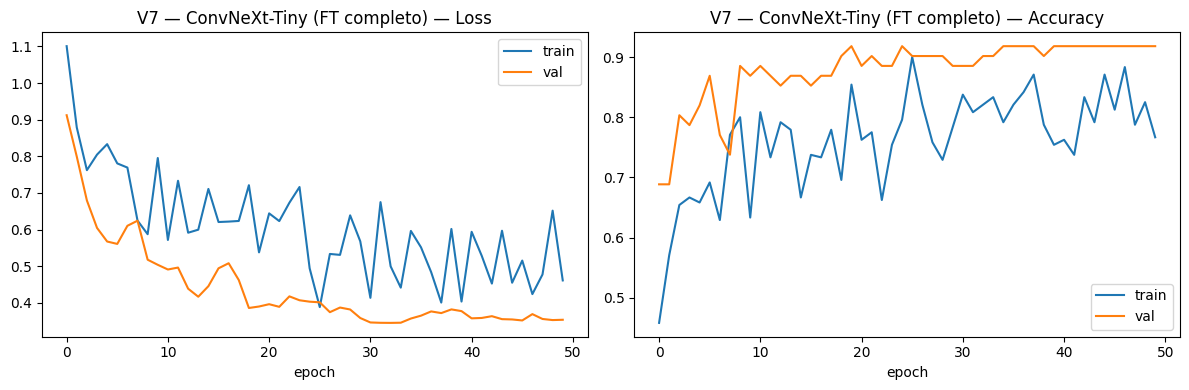

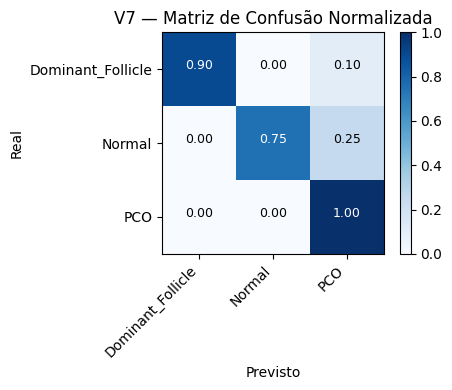

                   precision    recall  f1-score   support

Dominant_Follicle       1.00      0.90      0.95        29
           Normal       1.00      0.75      0.86         8
              PCO       0.83      1.00      0.91        24

         accuracy                           0.92        61
        macro avg       0.94      0.88      0.90        61
     weighted avg       0.93      0.92      0.92        61



In [ ]:
plot_curves(history_v7, "V7 — ConvNeXt-Tiny (FT completo)")
plot_cm(yt_v7, yp_v7, CLASS_NAMES, "V7", normalize=True)
print(classification_report(yt_v7, yp_v7, target_names=CLASS_NAMES))


> **Observação V7:** *(preencher após execução)*

---
## V8 · Pesado — ConvNeXt-Small (FT completo, RandAugment, Label Smoothing)

| Parâmetro | Valor |
|---|---|
| Backbone | ConvNeXt-**Small** — FT completo |
| Cabeça | LayerNorm + FC(1024) + GELU + Dropout(0.5) + FC |
| Augmentation | RandAugment + CutMix |
| Scheduler | CosineAnnealingWarmRestarts |
| Épocas | 60 |
| Resolução | 256 |
| LR | 5e-6 (backbone) / 5e-5 (cabeça) |
| Extras | Label Smoothing 0.1, WD=1e-4, TTA |

**Objetivo:** maior modelo, maior regularização — principal candidato ao ensemble.


In [ ]:
def build_v8():
    weights = ConvNeXt_Small_Weights.IMAGENET1K_V1
    model = convnext_small(weights=weights)
    for p in model.parameters():
        p.requires_grad = True
    in_feats = model.classifier[2].in_features
    model.classifier = nn.Sequential(
        model.classifier[0],
        model.classifier[1],
        nn.Linear(in_feats, 1024),
        nn.GELU(),
        nn.BatchNorm1d(1024),
        nn.Dropout(0.5),
        nn.Linear(1024, NUM_CLASSES),
    )
    return model.to(device)

# RandAugment entra no pipeline
def get_transforms_randaugment(img_size=256):
    normalize = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    train_tfms = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandAugment(num_ops=2, magnitude=9),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        normalize,
        transforms.RandomErasing(p=0.3, scale=(0.02, 0.2)),
    ])
    val_tfms = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        normalize,
    ])
    return train_tfms, val_tfms

train_tfms_v8, val_tfms_v8 = get_transforms_randaugment(img_size=256)
train_loader_v8, val_loader_v8 = make_loaders(train_tfms_v8, val_tfms_v8, batch_size=16)

model_v8 = build_v8()
print(f"Parâmetros treináveis: {sum(p.numel() for p in model_v8.parameters() if p.requires_grad):,}")


Parâmetros treináveis: 50,247,267


In [ ]:
EPOCHS_V8 = 60
criterion_v8 = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer_v8 = torch.optim.AdamW([
    {"params": model_v8.features.parameters(),   "lr": 5e-6},
    {"params": model_v8.classifier.parameters(), "lr": 5e-5},
], weight_decay=1e-4)
scheduler_v8 = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer_v8, T_0=20, T_mult=2)

print("\n=== Treinando V8 (ConvNeXt-Small FT completo + RandAugment + Label Smoothing) ===")
history_v8 = {k: [] for k in ["train_loss","val_loss","train_acc","val_acc","val_f1"]}
best_f1_v8, best_state_v8 = 0.0, None
t0_v8 = time.time()

for e in range(1, EPOCHS_V8 + 1):
    tr_loss, tr_acc, _, _, _       = train_cutmix_epoch(model_v8, train_loader_v8, optimizer_v8, criterion_v8)
    va_loss, va_acc, va_f1, yt, yp = run_epoch(model_v8, val_loader_v8, optimizer_v8, criterion_v8, train=False)
    scheduler_v8.step()

    for k, v in zip(history_v8.keys(), [tr_loss, va_loss, tr_acc, va_acc, va_f1]):
        history_v8[k].append(v)
    if va_f1 > best_f1_v8:
        best_f1_v8, best_state_v8 = va_f1, deepcopy(model_v8.state_dict())
        yt_v8, yp_v8 = yt, yp
    print(f"  [{e:>3}/{EPOCHS_V8}] loss {tr_loss:.4f}/{va_loss:.4f}  acc {tr_acc:.4f}/{va_acc:.4f}  f1 {va_f1:.4f}")

model_v8.load_state_dict(best_state_v8)
elapsed_v8 = (time.time() - t0_v8) / 60

print("  → Aplicando TTA...")
tta_acc_v8, tta_f1_v8, yt_v8, yp_v8 = tta_predict(model_v8, val_loader_v8, img_size=256)
print(f"  TTA  acc={tta_acc_v8:.4f}  f1={tta_f1_v8:.4f}")

res_v8 = {
    "variacao": "V8 ConvNeXt-S FT+TTA",
    "backbone": "ConvNeXt-S (FT completo, TTA)",
    "accuracy": round(tta_acc_v8, 4),
    "f1_macro": round(tta_f1_v8,  4),
    "precision": round(precision_score(yt_v8, yp_v8, average="macro", zero_division=0), 4),
    "recall":    round(recall_score(yt_v8, yp_v8, average="macro", zero_division=0), 4),
    "loss":      round(history_v8["val_loss"][-1], 4),
    "tempo_min": round(elapsed_v8, 1),
}
ALL_RESULTS.append(res_v8)
show_results(res_v8)

save_model(model_v8, res_v8["variacao"])


=== Treinando V8 (ConvNeXt-Small FT completo + RandAugment + Label Smoothing) ===
  [  1/60] loss 1.1660/0.8956  acc 0.4250/0.6885  f1 0.7186
  [  2/60] loss 1.0077/0.7361  acc 0.5375/0.8033  f1 0.8159
  [  3/60] loss 0.9517/0.6721  acc 0.6333/0.7705  f1 0.7901
  [  4/60] loss 0.9098/0.6461  acc 0.6417/0.7705  f1 0.7885
  [  5/60] loss 0.9644/0.6356  acc 0.5583/0.8033  f1 0.7972
  [  6/60] loss 0.9177/0.5904  acc 0.5917/0.8361  f1 0.8413
  [  7/60] loss 0.9344/0.5682  acc 0.5958/0.8689  f1 0.8654
  [  8/60] loss 0.8782/0.5597  acc 0.6042/0.8689  f1 0.8654
  [  9/60] loss 0.8763/0.5738  acc 0.7000/0.8689  f1 0.8660
  [ 10/60] loss 0.9387/0.5704  acc 0.6750/0.8852  f1 0.8785
  [ 11/60] loss 0.8601/0.5814  acc 0.6375/0.8852  f1 0.8785
  [ 12/60] loss 0.7889/0.5541  acc 0.7000/0.8525  f1 0.8534
  [ 13/60] loss 0.8502/0.5508  acc 0.6417/0.8852  f1 0.8785
  [ 14/60] loss 0.8041/0.5491  acc 0.6833/0.8525  f1 0.8538
  [ 15/60] loss 0.8193/0.5415  acc 0.6417/0.8525  f1 0.8534
  [ 16/60] loss 0

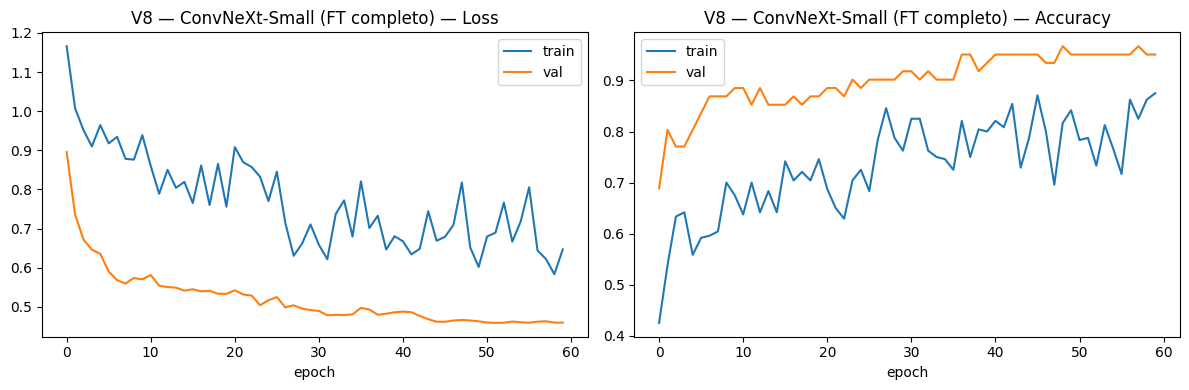

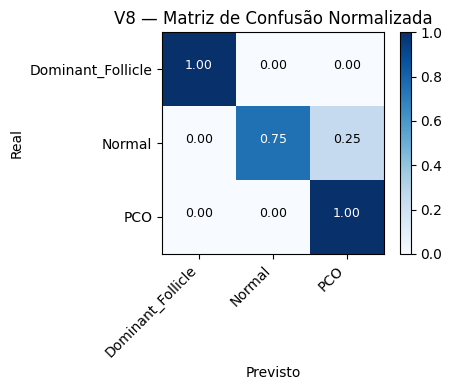

                   precision    recall  f1-score   support

Dominant_Follicle       1.00      1.00      1.00        29
           Normal       1.00      0.75      0.86         8
              PCO       0.92      1.00      0.96        24

         accuracy                           0.97        61
        macro avg       0.97      0.92      0.94        61
     weighted avg       0.97      0.97      0.97        61



In [ ]:
plot_curves(history_v8, "V8 — ConvNeXt-Small (FT completo)")
plot_cm(yt_v8, yp_v8, CLASS_NAMES, "V8", normalize=True)
print(classification_report(yt_v8, yp_v8, target_names=CLASS_NAMES))


> **Observação V8:** *(preencher após execução)*

---
## Consolidação Final — Todos os Resultados


In [ ]:
print("\n=== TABELA CONSOLIDADA ===")
print_results_table()



=== TABELA CONSOLIDADA ===
Var    Backbone                          Acc     F1   Prec    Rec   Loss  Tempo
───────────────────────────────────────────────────────────────────────────────
V7 ConvNeXt-T FT+TTA ConvNeXt-T (FT completo, TTA)  0.9180 0.9028 0.9425 0.8822 0.3535  14.3m
V8 ConvNeXt-S FT+TTA ConvNeXt-S (FT completo, TTA)  0.9672 0.9390 0.9744 0.9167 0.4599  19.0m


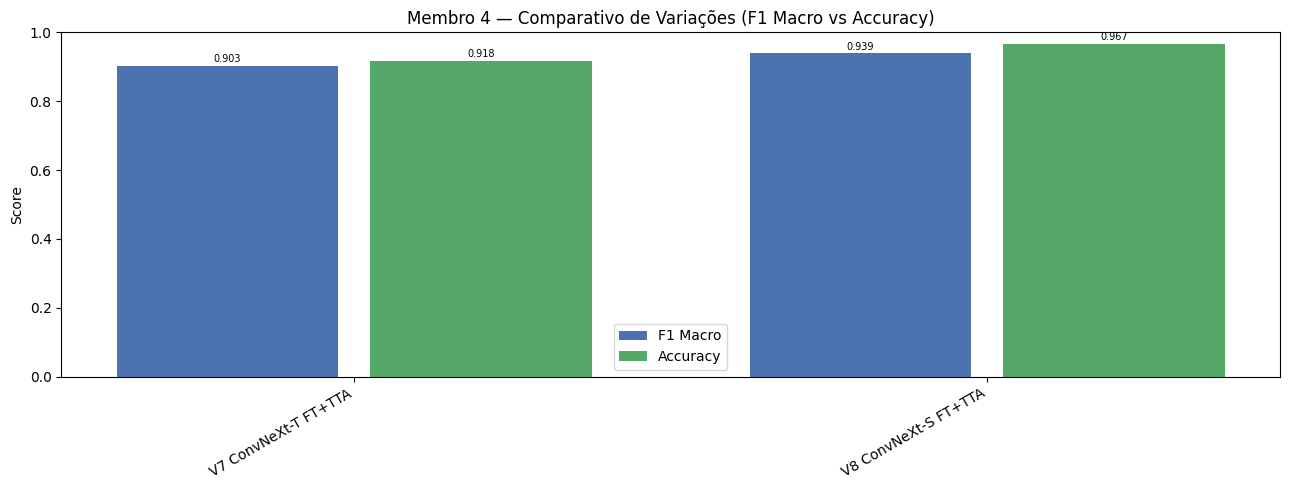

In [ ]:
# Gráfico comparativo de F1 Macro entre variações
if ALL_RESULTS:
    nomes = [r["variacao"] for r in ALL_RESULTS]
    f1s   = [r["f1_macro"] for r in ALL_RESULTS]
    accs  = [r["accuracy"] for r in ALL_RESULTS]

    x = np.arange(len(nomes))
    fig, ax = plt.subplots(figsize=(13, 5))
    bars = ax.bar(x - 0.2, f1s,  0.35, label="F1 Macro", color="#4C72B0")
    bars2= ax.bar(x + 0.2, accs, 0.35, label="Accuracy",  color="#55A868")
    ax.set_xticks(x); ax.set_xticklabels(nomes, rotation=30, ha="right")
    ax.set_ylim(0, 1); ax.set_ylabel("Score"); ax.legend()
    ax.set_title("Membro 4 — Comparativo de Variações (F1 Macro vs Accuracy)")
    for b in list(bars) + list(bars2):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
                f"{b.get_height():.3f}", ha="center", fontsize=7)
    plt.tight_layout(); plt.show()


---
## Notas para o Relatório

Copie esta tabela para o documento do grupo após preencher todas as variações:

| Var. | Backbone | Accuracy | F1 Macro | Precision | Recall | Tempo | Observações |
|---|---|---|---|---|---|---|---|
| V1 | MobileNetV3-L frozen | | | | | | |
| V2 | ConvNeXt-T frozen | | | | | | |
| V3 | ConvNeXt-T stage3 livre | | | | | | |
| V4 | ConvNeXt-T stage3 + Scheduler | | | | | | |
| V5 | ConvNeXt-T 2 stages | | | | | | |
| V6 | ConvNeXt-S 2 stages 256px | | | | | | |
| V7 | ConvNeXt-T FT completo + TTA | | | | | | |
| V8 | ConvNeXt-S FT completo + TTA | | | | | | |
